In [1]:
import sys
sys.path.append('..')

In [2]:
from utils.LidarCalibration import *
from utils.depol_tools import *

In [3]:

h5_colocalisation_data = "/homedata/ahaddouche/SIRTA_ATLID_COL/colocalisation_4_h_LAT_LON_300_km/H5/2025-06-11.h5"
rs_file = "/bdd/GRUAN/RADIOSONDAGE/L2_TMP/TRP/2025/2025_06_10/rs_2a_GRUAN_TRP_M10_20250610_231546_v2.0.1.nc"


Gamma = -0.01


In [4]:
data = read_hdf5_file(h5_colocalisation_data)
print(data.keys())
data_sirta = data['IPRAL']
data_atlid_l1 = data['ATLID_L1_300km']
data_atlid_l2 = data['ATLID_L2_300km']


<KeysViewHDF5 ['ATLID_L1_300km', 'ATLID_L2_300km', 'IPRAL']>


In [5]:
time_sirta= np.array(days_since_1970_to_datetime(data_sirta["time"]))
alt_sirta = np.array(data_sirta["range"])

In [6]:
rcs_12_rc = get_corrected_signal( data_sirta , alt_sirta ,rcs_="rcs_12")
rcs_02_rc = get_corrected_signal( data_sirta , alt_sirta ,rcs_="rcs_02")
rcs_03_rc = get_corrected_signal( data_sirta , alt_sirta ,rcs_="rcs_03")
rcs_04_rc = get_corrected_signal( data_sirta , alt_sirta ,rcs_="rcs_04")
rcs_05_rc = get_corrected_signal( data_sirta , alt_sirta ,rcs_="rcs_05")

print(np.shape(rcs_12_rc))
print(np.shape(time_sirta))
print(np.shape(alt_sirta))

# (2428, 4000)


(2743, 4000)
(2743,)
(4000,)


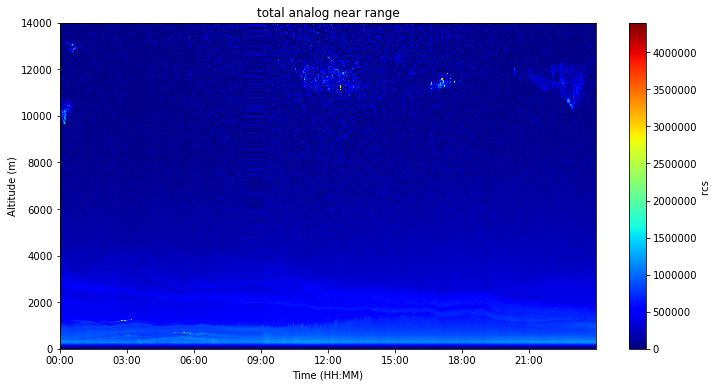

In [7]:
plt.figure(figsize=(12, 6))

vmax= np.percentile(rcs_12_rc , 98)
plot_rcs(rcs_12_rc , time_sirta , alt_sirta , "total analog near range" , vmax=vmax , vmin=0 , y_limit=(0,14000), save=False) 

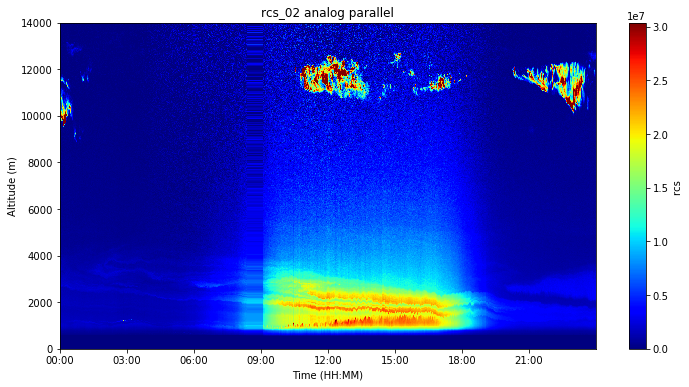

In [8]:
plt.figure(figsize=(12, 6)) 
vmax= np.percentile(rcs_02_rc , 97)
plot_rcs(rcs_02_rc , time_sirta , alt_sirta ,"rcs_02 analog parallel" , vmax=vmax , vmin=0 , y_limit=(0,14000) , save=False) 
# plt.axvline(datetime(2025, 5, 24, 1, 0), color='red', linestyle='--', label='ATLID observation time')
# plt.axvline(datetime(2025, 5, 24, 2, 0), color='red', linestyle='--', label='ATLID observation time') 

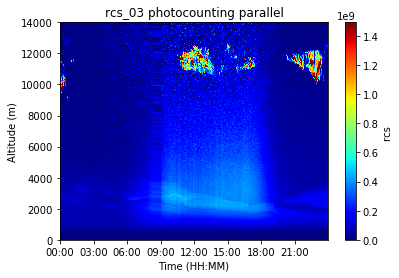

In [9]:

vmax= np.percentile(rcs_03_rc , 97)
plot_rcs(rcs_03_rc , time_sirta , alt_sirta , "rcs_03 photocounting parallel" , vmax=vmax , vmin=0 ,  y_limit=(0,14000), save=False)  


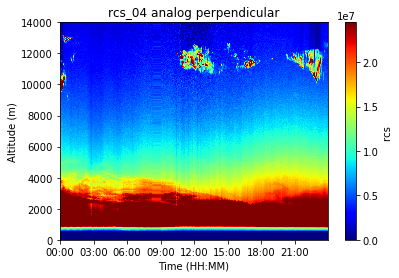

In [10]:
vmax= np.percentile(rcs_04_rc , 97)
plot_rcs(rcs_04_rc , time_sirta , alt_sirta , "rcs_04 analog perpendicular" , vmax=vmax , vmin=0 , y_limit=(0,14000), save=False) 

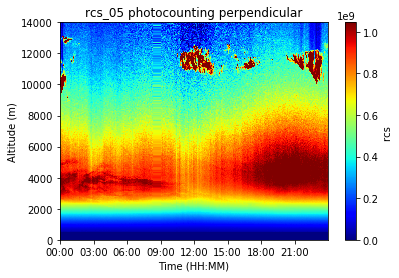

In [11]:

vmax= np.percentile(rcs_05_rc , 97)

plot_rcs(rcs_05_rc , time_sirta , alt_sirta , "rcs_05 photocounting perpendicular" , vmax=vmax , vmin=0 , y_limit=(0,14000), save=False) 

# Clear sky

In [12]:
start_time_clear='2025-06-11T01:30:00'
end_time_clear='2025-06-11T01:50:00'
index_clear =np.array( get_indx_from_range_time_sirta(start_time_clear , end_time_clear , time_sirta))
selected_time = time_sirta[index_clear]

In [13]:
conc , alt_rs , temp = conc_calculation(rs_file)

# plt.plot(temp, alt_rs)
# plt.title("temperature profile")

In [14]:
depolarization_ratio = 0.004
AMB_clear  , beta_ray , alpha_ray =  calculate_AMB_clear( conc, alt_rs, alt_sirta  )
AMB_clear_parallel = AMB_clear / (1 + depolarization_ratio)
AMB_clear_perpendicular = (AMB_clear * depolarization_ratio )/ (1 + depolarization_ratio)

beta_ray_parallel = beta_ray / (1 + depolarization_ratio)
beta_ray_perpendicular = (beta_ray * depolarization_ratio) / (1 + depolarization_ratio)

In [15]:
AMB_clear =remove_nans_interpolation(AMB_clear, alt_sirta)
AMB_clear_parallel =remove_nans_interpolation(AMB_clear_parallel, alt_sirta)
AMB_clear_perpendicular =remove_nans_interpolation(AMB_clear_perpendicular, alt_sirta)

beta_ray = remove_nans_interpolation(beta_ray, alt_sirta)
beta_ray_parallel = remove_nans_interpolation(beta_ray_parallel, alt_sirta)
beta_ray_perpendicular = remove_nans_interpolation(beta_ray_perpendicular, alt_sirta)   

### calibration for analog 

In [16]:
analog_parallel_clear=np.nanmean( rcs_04_rc[index_clear , :] , axis=0 )
analog_perpendicular_clear= np.nanmean( rcs_02_rc[index_clear , :] , axis=0 )

# filtering
analog_parallel_clear=gaussian_filter(analog_parallel_clear , alt_sirta , max_sigma=5  )
analog_perpendicular_clear=gaussian_filter(analog_perpendicular_clear , alt_sirta , max_sigma=5  )  


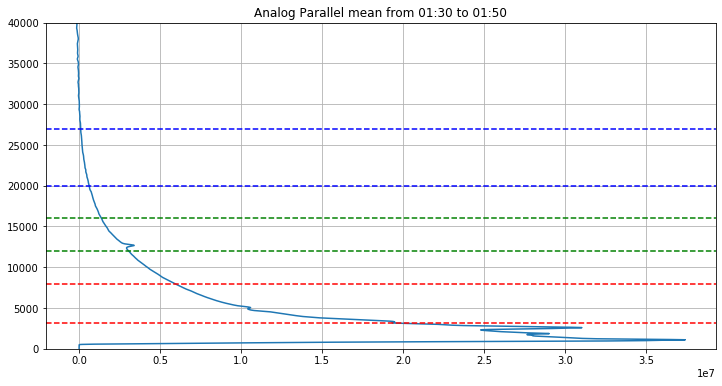

In [17]:
mask1_analog_par=[3200 , 8000]
mask2_analog_par=[12000 , 16000]
mask3_analog_par=[20000 , 27000]



plt.figure(figsize=(12, 6))
plt.title(f"Analog Parallel mean from {start_time_clear[11:16]} to {end_time_clear[11:16]}")
plt.plot(analog_parallel_clear , alt_sirta)
plt.axhline(y=mask1_analog_par[0], color='r', linestyle='--')
plt.axhline(y=mask1_analog_par[1], color='r', linestyle='--' )
plt.axhline(y=mask2_analog_par[0], color='g', linestyle='--')
plt.axhline(y=mask2_analog_par[1], color='g', linestyle='--')
plt.axhline(y=mask3_analog_par[0], color='b', linestyle='--')
plt.axhline(y=mask3_analog_par[1], color='b', linestyle='--')
plt.ylim(0 , 40000)
plt.grid(True)

# plt.savefig("figures/Analog_Parallel_clear.png")


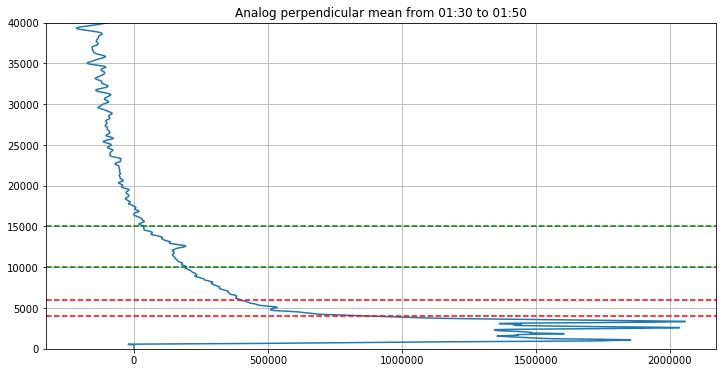

In [18]:

mask1_analog_per=[4000 , 6000]
mask2_analog_per=[10000 , 15000]

plt.figure(figsize=(12, 6))
plt.title(f"Analog perpendicular mean from {start_time_clear[11:16]} to {end_time_clear[11:16]}")
plt.plot(analog_perpendicular_clear , alt_sirta)

plt.axhline(y=mask1_analog_per[0], color='r', linestyle='--')
plt.axhline(y=mask1_analog_per[1], color='r', linestyle='--' )
plt.axhline(y=mask2_analog_per[0], color='g', linestyle='--')
plt.axhline(y=mask2_analog_per[1], color='g', linestyle='--')


plt.ylim(0 , 40000)
plt.grid(True)
# plt.savefig("figures/Analog_Perpendicular_clear.png")   

In [19]:
K_0_an_par , delta_0_an_par =Calibration(analog_parallel_clear , AMB_clear_parallel , alt_sirta ,  mask1_analog_par , mask2_analog_par , visual=False ) 

K_analog_par, delta_analog_par, result = optimize(analog_parallel_clear, AMB_clear_parallel, alt_sirta,[mask1_analog_par, mask2_analog_par ,mask3_analog_par ],K_0_an_par, delta_0_an_par ,  method='Nelder-Mead')



analog_parallel_clear_corrected = (analog_parallel_clear - delta_analog_par)
ATB_analog_par = K_analog_par * analog_parallel_clear_corrected

print("initiale K:", K_0_an_par, "delta:", delta_0_an_par)
print("optimized K:", K_analog_par, "delta:", delta_analog_par)

initiale K: 2.670553496242666e-13 delta: -216303.76034533043
optimized K: 1.9919799377873105e-13 delta: -1648103.1437641168


In [20]:
analog_perpendicular_clear_ = analog_perpendicular_clear + Gamma* analog_parallel_clear_corrected


K_0_an_per , delta_0_an_per =Calibration(analog_perpendicular_clear_ , AMB_clear_perpendicular , alt_sirta ,  mask1_analog_per , mask2_analog_per , visual=False ) 
K_analog_per, delta_analog_per, result = optimize(analog_perpendicular_clear_, AMB_clear_perpendicular, alt_sirta,[mask1_analog_per, mask2_analog_per  ],K_0_an_per, delta_0_an_per ,  method='Nelder-Mead')

analog_perpendicular_clear_corrected =  (analog_perpendicular_clear_ - delta_analog_per)
ATB_analog_per = K_analog_per * analog_perpendicular_clear_corrected

print("initiale K:", K_0_an_per, "delta:", delta_0_an_per)
print("optimized K:", K_analog_per, "delta:", delta_analog_per)

initiale K: 2.6032350999924938e-14 delta: -46685.206942990095
optimized K: 2.2756383953594585e-14 delta: -72121.63233898825


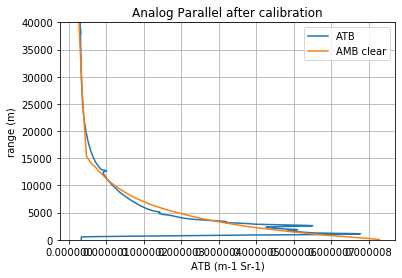

In [21]:
plt.figure()
plt.title("Analog Parallel after calibration")  

plt.plot(ATB_analog_par , alt_sirta , label="ATB")
plt.plot(AMB_clear_parallel , alt_sirta , label="AMB clear")
plt.ylim((0, 40000))
plt.grid(True)
plt.xlabel("ATB (m-1 Sr-1)")
plt.ylabel("range (m)")
plt.legend()
# plt.savefig("figures/Analog_Parallel_after_calibration.png")



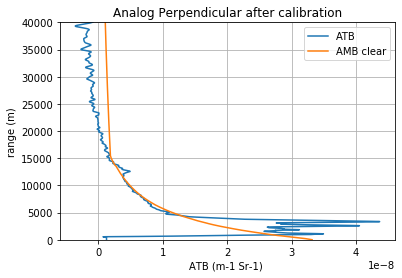

In [22]:
plt.figure()
plt.plot(ATB_analog_per , alt_sirta, label="ATB")
plt.plot(AMB_clear_perpendicular , alt_sirta, label="AMB clear")
plt.ylim((0, 40000))
plt.grid(True)
plt.title("Analog Perpendicular after calibration")
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
# plt.savefig("figures/Analog_Perpendicular_after_calibration.png")



### calibration for photocounting

In [23]:
photocounting_parallel_clear= np.nanmean( rcs_05_rc[index_clear , :] , axis=0 )
photocounting_perpendicular_clear= np.nanmean( rcs_03_rc[index_clear , :] , axis=0 )


# filtering 
photocounting_parallel_clear=gaussian_filter(photocounting_parallel_clear , alt_sirta , max_sigma=5  )
photocounting_perpendicular_clear=gaussian_filter(photocounting_perpendicular_clear , alt_sirta , max_sigma=5  )


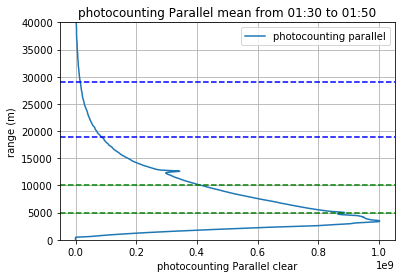

In [24]:


mask1_photo_par=[5000 , 10000]
mask2_photo_par=[19000 , 29000]



plt.figure()
plt.title(f"photocounting Parallel mean from {start_time_clear[11:16]} to {end_time_clear[11:16]}")
plt.plot(photocounting_parallel_clear , alt_sirta, label="photocounting parallel")
plt.axhline(y=mask1_photo_par[0], color='g', linestyle='--')
plt.axhline(y=mask1_photo_par[1], color='g', linestyle='--')
plt.axhline(y=mask2_photo_par[0], color='b', linestyle='--')
plt.axhline(y=mask2_photo_par[1], color='b', linestyle='--')
plt.ylim(0 , 40000)
plt.grid(True)
plt.xlabel("photocounting Parallel clear")
plt.ylabel("range (m)")
plt.legend()
# plt.savefig("figures/Photocounting_Parallel_clear.png")




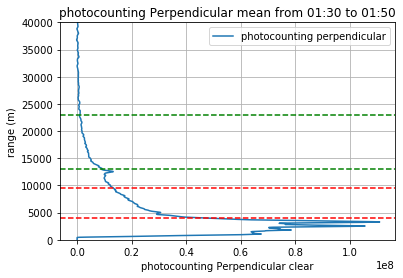

In [25]:


mask1_photo_per=[4000 , 9500]
mask2_photo_per=[13000 , 23000]

plt.figure()
plt.title(f"photocounting Perpendicular mean from {start_time_clear[11:16]} to {end_time_clear[11:16]}")
plt.plot(photocounting_perpendicular_clear , alt_sirta, label="photocounting perpendicular")
plt.axhline(y=mask1_photo_per[0], color='r', linestyle='--')
plt.axhline(y=mask1_photo_per[1], color='r', linestyle='--' )
plt.axhline(y=mask2_photo_per[0], color='g', linestyle='--')
plt.axhline(y=mask2_photo_per[1], color='g', linestyle='--')
plt.ylim(0 , 40000)
plt.grid(True)
plt.xlabel("photocounting Perpendicular clear")
plt.ylabel("range (m)")
plt.legend()

# plt.savefig("figures/Photocounting_Perpendicular_clear.png")




In [26]:
K_0_ph_par , delta_0_ph_par =Calibration(photocounting_parallel_clear , AMB_clear_parallel , alt_sirta ,  mask1_photo_par , mask2_photo_par , visual=False ) 

K_ph_par, delta_ph_par, result = optimize(photocounting_parallel_clear, AMB_clear_parallel, alt_sirta,[ mask1_photo_par , mask2_photo_par],K_0_ph_par, delta_0_ph_par ,  method='Nelder-Mead')
photocounting_parallel_clear_corrected = photocounting_parallel_clear - delta_ph_par

ATB_ph_par = K_ph_par * photocounting_parallel_clear_corrected

print("initiale K:", K_0_ph_par, "delta:", delta_0_ph_par)
print("optimized K:", K_ph_par, "delta:", delta_ph_par)

initiale K: 2.6038235076663246e-15 delta: -107396881.48326574
optimized K: 2.433845766018757e-15 delta: -123518035.1893259


In [27]:
photocounting_perpendicular_clear_ = photocounting_perpendicular_clear + Gamma* photocounting_parallel_clear_corrected


K_0_ph_per , delta_0_ph_per =Calibration(photocounting_perpendicular_clear_ , AMB_clear_perpendicular , alt_sirta ,  mask1_photo_per , mask2_photo_per , visual=False ) 

K_ph_per, delta_ph_per, result = optimize(photocounting_perpendicular_clear_, AMB_clear_perpendicular, alt_sirta,[mask1_photo_per, mask2_photo_per , mask2_photo_per],K_0_ph_per, delta_0_ph_per ,  method='Nelder-Mead')


ATB_ph_per = K_ph_per * (photocounting_perpendicular_clear_ - delta_ph_per)

print("initiale K:", K_0_ph_per, "delta:", delta_0_ph_per)
print("optimized K:", K_ph_per, "delta:", delta_ph_per)

initiale K: 5.4831986530702e-16 delta: -2285533.922029161
optimized K: 4.915378880877184e-16 delta: -3082917.431324876


(0, 40000)

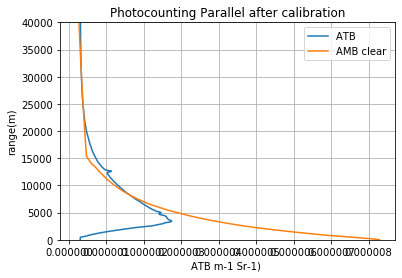

In [28]:
plt.figure()
plt.title("Photocounting Parallel after calibration")   
plt.plot(ATB_ph_par , alt_sirta, label="ATB ")
plt.plot(AMB_clear_parallel , alt_sirta, label="AMB clear")
plt.grid(True)
plt.ylabel("range(m)")
plt.xlabel("ATB m-1 Sr-1) ")
plt.legend()
plt.ylim((0,40000))
# plt.savefig("figures/Photocounting_Parallel_after_calibration.png")


(0, 40000)

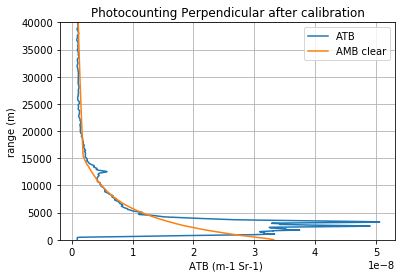

In [29]:
plt.figure()
plt.title("Photocounting Perpendicular after calibration")
plt.plot(ATB_ph_per , alt_sirta, label="ATB")
plt.plot(AMB_clear_perpendicular , alt_sirta, label="AMB clear")
plt.grid(True)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.ylim((0,40000))
# plt.savefig("figures/Photocounting_Perpendicular_after_calibration.png")


### coller parallel 

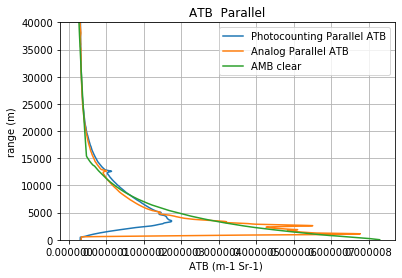

In [30]:
plt.figure()
plt.title("ATB  Parallel")
plt.plot(ATB_ph_par , alt_sirta , label='Photocounting Parallel ATB')
plt.plot(ATB_analog_par , alt_sirta , label='Analog Parallel ATB')
plt.plot(AMB_clear_parallel , alt_sirta , label='AMB clear')
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)

# plt.savefig("figures/Photocounting_Parallel_after_calibration.png")


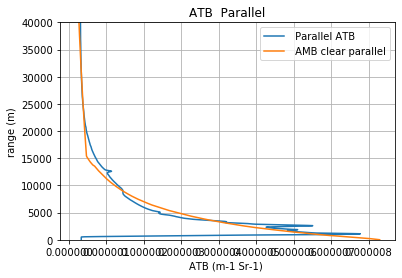

In [31]:
mask_transition_parallel=[8000 , 9500]
ATB_par_Clear= merged_signal_hanning(ATB_analog_par, ATB_ph_par, alt_sirta, transition_start=mask_transition_parallel[0], transition_end=mask_transition_parallel[1])


plt.figure()
plt.title("ATB  Parallel")
plt.plot(ATB_par_Clear , alt_sirta , label=' Parallel ATB')  
plt.plot(AMB_clear_parallel, alt_sirta , label=' AMB clear parallel' )   
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)
# plt.savefig("figures/ATB_Parallel_after_calibration.png")   

### coller perpendicular

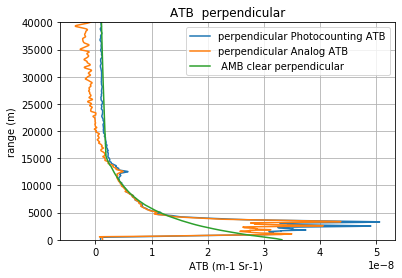

In [32]:
plt.figure()
plt.title("ATB  perpendicular")
plt.plot(ATB_ph_per, alt_sirta , label='perpendicular Photocounting ATB')
plt.plot(ATB_analog_per, alt_sirta , label='perpendicular Analog ATB')
plt.plot(AMB_clear_perpendicular , alt_sirta , label=' AMB clear perpendicular' )
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)
# plt.savefig("figures/ATB_Perpendicular_after_calibration.png")

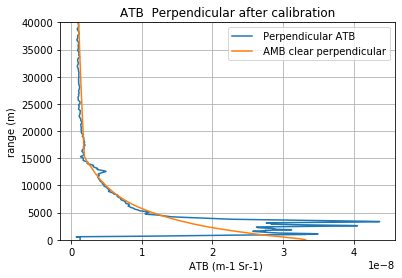

In [33]:
mask_transition_perpendicular=[15000 , 18000]

ATB_per_Clear = merged_signal_hanning(ATB_analog_per, ATB_ph_per, alt_sirta, transition_start=mask_transition_perpendicular[0], transition_end=mask_transition_perpendicular[1])

plt.figure()
plt.title("ATB  Perpendicular after calibration")
plt.plot(ATB_per_Clear , alt_sirta , label=' Perpendicular ATB')  
plt.plot(AMB_clear_perpendicular, alt_sirta , label=' AMB clear perpendicular' )   
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)


In [34]:
# filter the signals

# ATB_per_Clear = gaussian_filter(ATB_per_Clear , alt_sirta , max_sigma=1  )
# ATB_par_Clear = gaussian_filter(ATB_par_Clear , alt_sirta , max_sigma=1 )   
ATB_total_clear= ATB_per_Clear + ATB_par_Clear
print(np.shape(ATB_total_clear))


(4000,)


### atb total

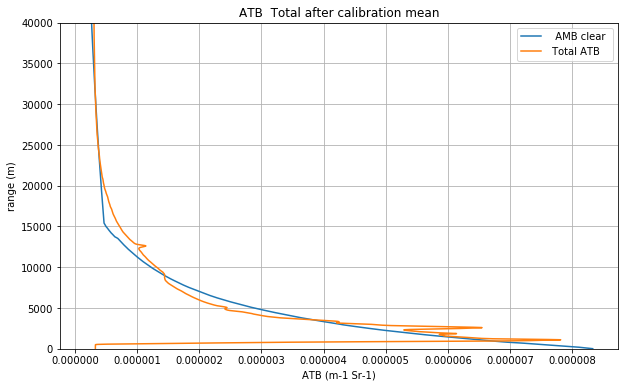

In [35]:
plt.figure(figsize=(10,6))
plt.title(f"ATB  Total after calibration mean" )   
plt.plot(AMB_clear , alt_sirta , label='  AMB clear ' )
plt.plot(ATB_total_clear , alt_sirta , label=' Total ATB ')
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1)")
plt.ylabel("range (m)")
plt.grid(True)

plt.legend()


### klett inversion

In [36]:
## take care of nan values

ATB_per_Clear= remove_nans_interpolation(ATB_per_Clear, alt_sirta)
ATB_par_Clear = remove_nans_interpolation(ATB_par_Clear, alt_sirta)
ATB_total_clear = remove_nans_interpolation(ATB_total_clear, alt_sirta)
AMB_clear = remove_nans_interpolation(AMB_clear, alt_sirta)
beta_ray = remove_nans_interpolation(beta_ray, alt_sirta)
beta_ray_parallel = remove_nans_interpolation(beta_ray_parallel, alt_sirta)
beta_ray_perpendicular = remove_nans_interpolation(beta_ray_perpendicular, alt_sirta)



In [37]:
INDEX_FOR_THE_CALIBRATION = 20000  # in  km 
LR = 30
reference_range = 50 

beta_aerosol_total_clear , __=L1_2_L2(ATB_total_clear  , INDEX_FOR_THE_CALIBRATION , alt_sirta , beta_ray , LR =LR
            , reference_range = reference_range , beta_aerosol_reference = 1e-9 ) 

beta_aerosol_par_clear , __=L1_2_L2(ATB_par_Clear  , INDEX_FOR_THE_CALIBRATION , alt_sirta , beta_ray_parallel , LR =LR
            , reference_range = reference_range , beta_aerosol_reference = 1e-9 ) 

beta_aerosol_per_clear , __=L1_2_L2(ATB_per_Clear  , INDEX_FOR_THE_CALIBRATION , alt_sirta , beta_ray_perpendicular , LR =LR
            , reference_range = reference_range , beta_aerosol_reference = 1e-9 ) 

calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m


(-2e-06, 1e-05)

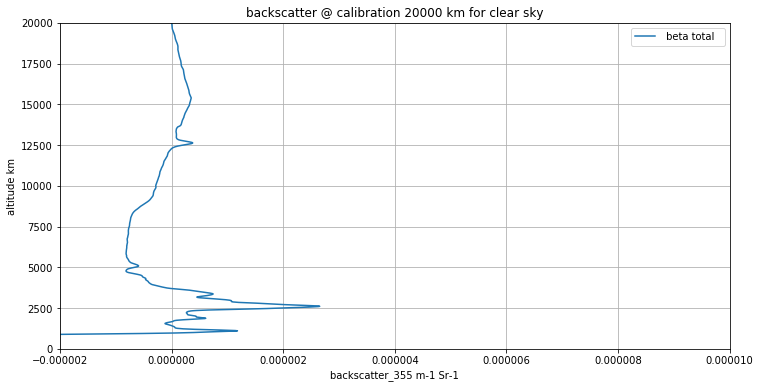

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(beta_aerosol_total_clear , alt_sirta , label = " beta total  ")
plt.xlabel("backscatter_355 m-1 Sr-1")
plt.ylabel("altitude km")
plt.title(f"backscatter @ calibration {INDEX_FOR_THE_CALIBRATION} km for clear sky")
plt.grid("True")
plt.legend()
plt.ylim((000,20000))
plt.xlim((-2e-6,1e-5))
# plt.savefig("figures/backscatter_aerosol_clear_calibrated.png")

# cloudy sky 

In [43]:
start_time_cloud='2025-06-11T00:30:00'
end_time_cloud='2025-06-11T01:30:00'



index_cloud =np.array( get_indx_from_range_time_sirta(start_time_cloud , end_time_cloud , time_sirta))
selected_time = time_sirta[index_cloud]

### calibrate parallel in cloudy period


In [44]:
# calibrate parallel in cloudy period

ATB_analog_par_corrected_avrg , ATB_analog_par_corrected_selected = calibrate_signal(time_sirta, alt_sirta, rcs_04_rc , delta_analog_par, start_time_cloud, end_time_cloud)   
ATB_ph_par_corrected_avrg, ATB_ph_par_corrected_selected = calibrate_signal(time_sirta, alt_sirta, rcs_05_rc , delta_ph_par, start_time_cloud, end_time_cloud)


In [45]:

ATB_analog_par_cloud_avrg = K_analog_par * ATB_analog_par_corrected_avrg
ATB_analog_par_cloud_selected = K_analog_par * ATB_analog_par_corrected_selected

ATB_ph_par_cloud_avrg = K_ph_par * ATB_ph_par_corrected_avrg
ATB_ph_par_cloud_selected = K_ph_par * ATB_ph_par_corrected_selected


print("Analog parallel shape : ",np.shape(ATB_analog_par_cloud_selected), np.shape(ATB_analog_par_cloud_avrg))
print("photocountng parallel shape : ",np.shape(ATB_ph_par_cloud_selected), np.shape(ATB_ph_par_cloud_avrg))

Analog parallel shape :  (119, 4000) (4000,)
photocountng parallel shape :  (119, 4000) (4000,)


(4000,)
(119, 4000)


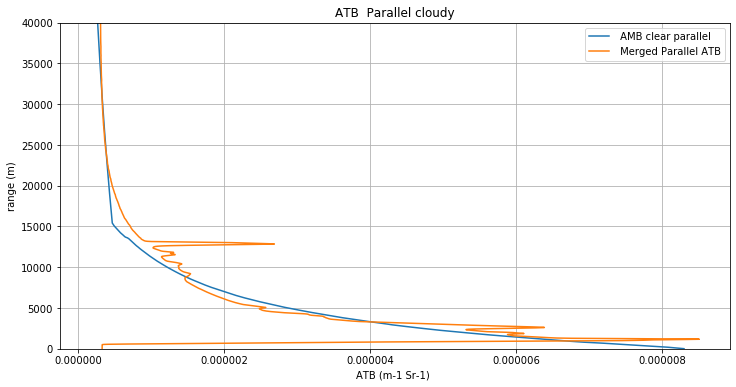

In [46]:

ATB_par_cloudy_avrg = merged_signal_hanning(ATB_analog_par_cloud_avrg, ATB_ph_par_cloud_avrg, alt_sirta, transition_start=mask_transition_parallel[0], transition_end=mask_transition_parallel[1])
ATB_par_cloudy_selected = merged_signal_hanning(ATB_analog_par_cloud_selected, ATB_ph_par_cloud_selected, alt_sirta, transition_start=mask_transition_parallel[0], transition_end=mask_transition_parallel[1])

plt.figure(figsize=(12, 6))
plt.title("ATB  Parallel cloudy")       
plt.plot(AMB_clear_parallel , alt_sirta , label=' AMB clear parallel' )  
plt.plot(ATB_par_cloudy_avrg , alt_sirta , label=' Merged Parallel ATB')  
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)

print(np.shape(ATB_par_cloudy_avrg))
print(np.shape(ATB_par_cloudy_selected))


### calibrate perpendicular in cloudy period


In [47]:
# calibrate perpendicular in cloudy period

ATB_analog_per_corrected_avrg, ATB_analog_per_corrected_selected = calibrate_signal(time_sirta, alt_sirta, rcs_02_rc , delta_analog_per, start_time_cloud, end_time_cloud)
ATB_ph_per_corrected_avrg, ATB_ph_per_corrected_selected = calibrate_signal(time_sirta, alt_sirta, rcs_03_rc , delta_ph_per, start_time_cloud, end_time_cloud)


In [48]:
ATB_analog_per_cloud_selected = K_analog_per * (ATB_analog_per_corrected_selected + Gamma * ATB_analog_par_corrected_selected)
ATB_analog_per_cloud_avrg = K_analog_per * (ATB_analog_per_corrected_avrg + Gamma * ATB_analog_par_corrected_avrg)


ATB_ph_per_cloud_selected = K_ph_per * (ATB_ph_per_corrected_selected + Gamma * ATB_ph_par_corrected_selected)
ATB_ph_per_cloud_avrg = K_ph_per * (ATB_ph_per_corrected_avrg + Gamma * K_ph_par * ATB_ph_par_corrected_avrg)

print("Analog perpendicular shape : ",np.shape(ATB_analog_per_cloud_selected), np.shape(ATB_analog_per_cloud_avrg))
print("photocountng perpendicular shape : ",np.shape(ATB_ph_per_cloud_selected), np.shape(ATB_ph_per_cloud_avrg))

Analog perpendicular shape :  (119, 4000) (4000,)
photocountng perpendicular shape :  (119, 4000) (4000,)


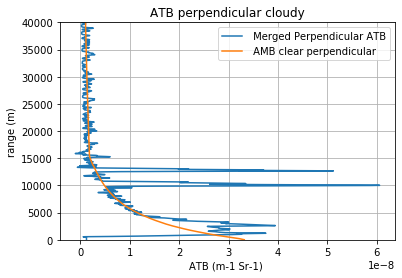

In [49]:
# calibrate perpendicular in cloudy period

ATB_per_cloudy_avrg = merged_signal_hanning(ATB_analog_per_cloud_avrg, ATB_ph_per_cloud_avrg, alt_sirta, transition_start=mask_transition_perpendicular[0], transition_end=mask_transition_perpendicular[1])
ATB_per_cloudy_selected = merged_signal_hanning(ATB_analog_per_cloud_selected, ATB_ph_per_cloud_selected, alt_sirta, transition_start=mask_transition_perpendicular[0], transition_end=mask_transition_perpendicular[1])

plt.figure()
plt.title("ATB perpendicular cloudy")       
# plt.plot(ATB_ph_per_cloud , alt_sirta , label=' ATB photocounting' )  
# plt.plot(ATB_analog_per_cloud , alt_sirta , label=' ATB analog')  
plt.plot(ATB_per_cloudy_selected[10,:] , alt_sirta , label=' Merged Perpendicular ATB')
plt.plot(AMB_clear_perpendicular , alt_sirta , label=' AMB clear perpendicular' )
plt.ylim(0 , 40000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.legend()
plt.grid(True)



shapes total cloudy avrg:  (4000,)
shapes total cloudy selected:  (119, 4000)
(119, 4000)


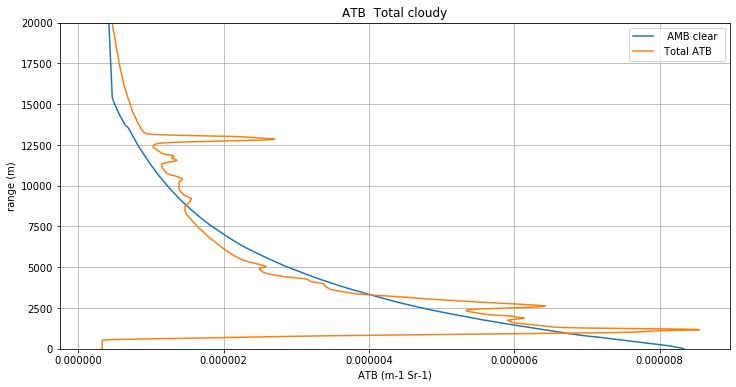

In [51]:
ATB_total_cloudy_avrg = ATB_par_cloudy_avrg + ATB_per_cloudy_avrg
ATB_total_cloudy_selected = ATB_par_cloudy_selected + ATB_per_cloudy_selected

print("shapes total cloudy avrg: ", np.shape(ATB_total_cloudy_avrg))
print("shapes total cloudy selected: ", np.shape(ATB_total_cloudy_selected))

plt.figure(figsize=(12, 6))
plt.title(f"ATB  Total cloudy")   
plt.plot(AMB_clear , alt_sirta , label='  AMB clear ' )
plt.plot(ATB_total_cloudy_avrg , alt_sirta , label=' Total ATB ')
plt.ylim(0 , 20000)
plt.xlabel("ATB (m-1 Sr-1)")
plt.ylabel("range (m)")
plt.grid(True)
plt.legend()

print(np.shape(ATB_total_cloudy_selected))

In [52]:
fitted_mask = [[3000, 12000], [13000, 16000]]
ATB_par_fitted =  np.full_like(ATB_par_cloudy_selected, np.nan)
ATB_per_fitted =  np.full_like(ATB_per_cloudy_selected, np.nan)


for i in range(ATB_per_cloudy_selected.shape[0]):
    ATB_par_fitted[i, :] = fit_clear_sky(alt_sirta, ATB_par_cloudy_selected[i, :], fitted_mask)
    ATB_per_fitted[i, :] = fit_clear_sky(alt_sirta, ATB_per_cloudy_selected[i, :], fitted_mask)

ATB_per_selected = ATB_per_cloudy_selected - ATB_per_fitted
ATB_par_selected = ATB_par_cloudy_selected - ATB_par_fitted


In [53]:
alt_min = 12500
alt_max = 13500

depol_final, mask_full = calculate_depolarization_ratio_range( ATB_par_selected , ATB_per_selected  , alt_sirta, alt_min=alt_min, alt_max=alt_max , threshold_factor=0.2)

Threshold for local mask: (119, 1)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]]


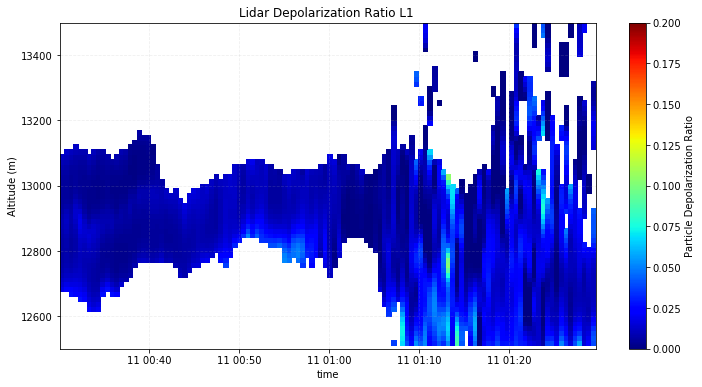

In [55]:

plt.figure(figsize=(12, 6))

pcm = plt.pcolormesh(selected_time, alt_sirta, depol_final.T , 
                     shading='auto', cmap='jet', vmin=0, vmax=0.2)

cbar = plt.colorbar(pcm)
cbar.set_label('Particle Depolarization Ratio')
# Décoration
plt.ylabel('Altitude (m)') 
plt.xlabel('time') 
plt.title('Lidar Depolarization Ratio L1 ')    

plt.ylim(alt_min, alt_max) 
plt.grid(True, linestyle='--', alpha=0.2)
plt.show()

In [57]:
INDEX_FOR_THE_CALIBRATION = 20000  # in  km 
LR = 20
reference_range = 50

beta_aerosol_total_cloudy_avrg , __=L1_2_L2(ATB_total_cloudy_avrg  , INDEX_FOR_THE_CALIBRATION , alt_sirta , beta_ray , LR =LR
            , reference_range = reference_range , beta_aerosol_reference = 1e-9 ) 


beta_aerosol_par_cloudy_avrg , __=L1_2_L2(ATB_par_cloudy_avrg  , INDEX_FOR_THE_CALIBRATION , alt_sirta , beta_ray_parallel , LR =LR
            , reference_range = reference_range , beta_aerosol_reference = 1e-9 ) 


beta_aerosol_per_cloudy_avrg , __=L1_2_L2(ATB_per_cloudy_avrg  , INDEX_FOR_THE_CALIBRATION , alt_sirta , beta_ray_perpendicular , LR =LR
            , reference_range = reference_range , beta_aerosol_reference = 1e-9 ) 



beta_aerosol_total_cloudy_avrg_fixed , mask_beta_par, mask_beta_per= filter_negative_backscatter(beta_parallel=beta_aerosol_par_cloudy_avrg, beta_perpendicular=beta_aerosol_per_cloudy_avrg)

calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m


(0, 15000)

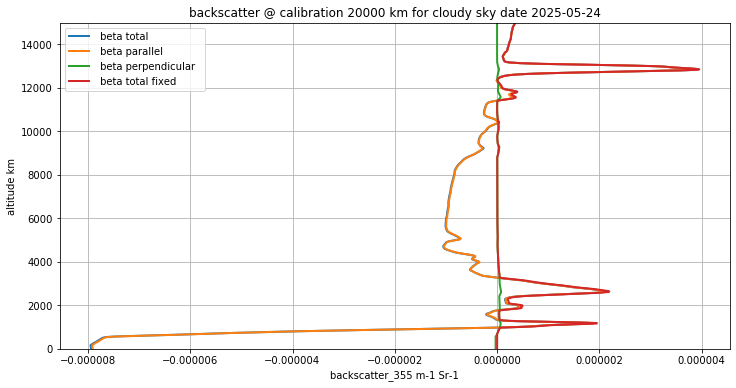

In [59]:


plt.figure(figsize=(12, 6))
plt.plot(beta_aerosol_total_cloudy_avrg , alt_sirta , label = " beta total  " , linewidth=2)
plt.plot(beta_aerosol_par_cloudy_avrg , alt_sirta , label = " beta parallel  " , linewidth=2)
plt.plot(beta_aerosol_per_cloudy_avrg , alt_sirta , label = " beta perpendicular  " , linewidth=2)
plt.plot(beta_aerosol_total_cloudy_avrg_fixed, alt_sirta , label = " beta total fixed " , linewidth=2)
plt.xlabel("backscatter_355 m-1 Sr-1")
plt.ylabel("altitude km")


plt.xlabel("backscatter_355 m-1 Sr-1")
plt.ylabel("altitude km")
plt.title(f"backscatter @ calibration {INDEX_FOR_THE_CALIBRATION} km for cloudy sky date 2025-05-24")
plt.grid("True")
plt.legend()
plt.ylim(0, 15000)
# plt.xlim((-2e-6,0.4e-5))
# plt.savefig("figures/backscatter_aerosol_cloudy_calibrated.png")

In [60]:
beta_aerosol_total =  np.full_like(ATB_total_cloudy_selected, np.nan)
beta_aerosol_total_fixed=  np.full_like(ATB_total_cloudy_selected, np.nan)
beta_aerosol_par =  np.full_like(ATB_par_cloudy_selected, np.nan)
beta_aerosol_per =  np.full_like(ATB_per_cloudy_selected, np.nan)

for i in range(ATB_total_cloudy_selected.shape[0]):

    beta_aerosol_total[i , :] , __=L1_2_L2(ATB_total_cloudy_selected[i , :] , INDEX_FOR_THE_CALIBRATION , alt_sirta , beta_ray , LR =LR
                , reference_range = reference_range , beta_aerosol_reference = 1e-9 )


    beta_aerosol_par[i , :] , __=L1_2_L2(ATB_par_cloudy_selected[i , :]  , INDEX_FOR_THE_CALIBRATION , alt_sirta , beta_ray_parallel , LR =LR
                , reference_range = reference_range , beta_aerosol_reference = 1e-9 )


    beta_aerosol_per[i , :] , __=L1_2_L2(ATB_per_cloudy_selected[i , :]  , INDEX_FOR_THE_CALIBRATION , alt_sirta , beta_ray_perpendicular , LR =LR
                , reference_range = reference_range, beta_aerosol_reference = 1e-9 )

    beta_aerosol_total_fixed[i,:] , mask_beta_par, mask_beta_per= filter_negative_backscatter(beta_parallel=beta_aerosol_par[i,:], beta_perpendicular=beta_aerosol_per[i,:])


calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20750.0 m
calibration range 19250.0 m  to 20

(-2e-06, 3e-05)

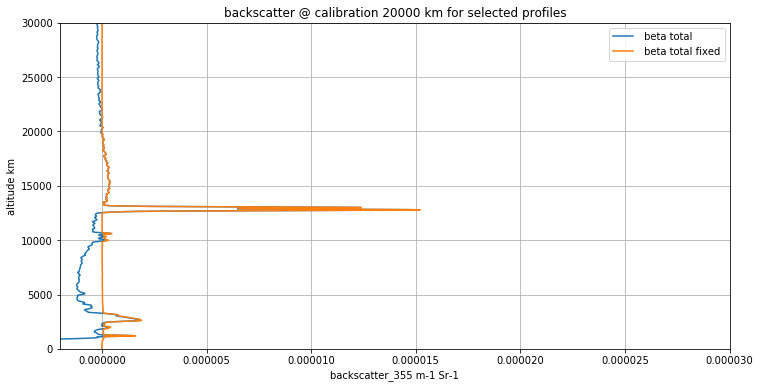

In [61]:
plt.figure(figsize=(12, 6))
plt.plot(beta_aerosol_total[10,:] , alt_sirta , label = " beta total")
plt.plot(beta_aerosol_total_fixed[10,:] , alt_sirta , label = " beta total fixed")
# plt.plot(beta_aerosol_par[10,:] , alt_sirta , label = " beta parallel")
# plt.plot(beta_aerosol_per[10,:] , alt_sirta , label = " beta perpendicular")
plt.xlabel("backscatter_355 m-1 Sr-1")
plt.ylabel("altitude km")
plt.title(f"backscatter @ calibration {INDEX_FOR_THE_CALIBRATION} km for selected profiles")
plt.grid("True")
plt.legend()
plt.ylim((000,30000))
plt.xlim((-2e-6,3e-5))

In [62]:
SR_ipral_L2 = 1+ (beta_aerosol_total_cloudy_avrg_fixed) / beta_ray
SR_L1 = ATB_total_cloudy_avrg /AMB_clear

#  comparison with ATLID 

In [64]:
min_indx_l2 = int(data_atlid_l2["min_index"][()])
interval = 5
start_idx = min_indx_l2 - interval
end_idx = min_indx_l2 + interval

backscatter_355_atlid = np.array(data_atlid_l2["particle_backscatter_coefficient_355nm"])
APB_355_atlid = np.array(data_atlid_l2["APB"])
AMB_355_atlid = np.array(data_atlid_l2["AMB"])
altitude_atlid = np.array(data_atlid_l2["height"])
print(np.shape(backscatter_355_atlid))

backscatter_355_atlid = np.where(backscatter_355_atlid > 1e35 , np.nan , backscatter_355_atlid)
APB_355_atlid = np.where(APB_355_atlid > 1e34 , np.nan , APB_355_atlid)
AMB_355_atlid = np.where(AMB_355_atlid > 1e34 , np.nan , AMB_355_atlid)
APB_355_atlid = np.where(APB_355_atlid < 0 , np.nan , APB_355_atlid)
AMB_355_atlid = np.where(AMB_355_atlid < 0 , np.nan , AMB_355_atlid)


best_index = 100
backscatter_355_atlid_avrg = backscatter_355_atlid[best_index,:]
# backscatter_355_atlid_avrg = np.nanmean(backscatter_355_atlid , axis=0)
APB_355_atlid_avrg = APB_355_atlid[:, best_index]
AMB_355_atlid_avrg = AMB_355_atlid[:, best_index]

SR_atlid = np.where(AMB_355_atlid_avrg != 0 , (APB_355_atlid_avrg  )/ AMB_355_atlid_avrg , np.nan)

print(np.shape(SR_atlid))


(592, 242)
(242,)


(0, 10)

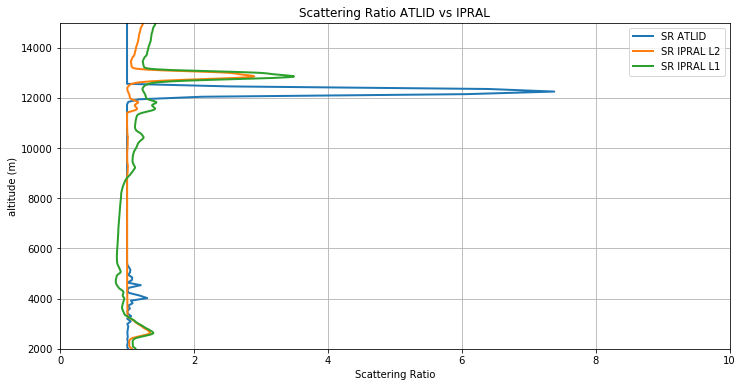

In [71]:
plt.figure(figsize=(12, 6))
plt.title("Scattering Ratio ATLID vs IPRAL")
plt.plot(SR_atlid , altitude_atlid[10 , :], label="SR ATLID " , linewidth=2)
plt.plot(SR_ipral_L2 , alt_sirta , label="SR IPRAL L2" , linewidth=2)
plt.plot(SR_L1 , alt_sirta , label="SR IPRAL L1" , linewidth=2)
plt.xlabel("Scattering Ratio")
plt.ylabel("altitude (m)")
plt.grid()
plt.legend()
plt.ylim((2000,15000))
plt.xlim((0, 10))

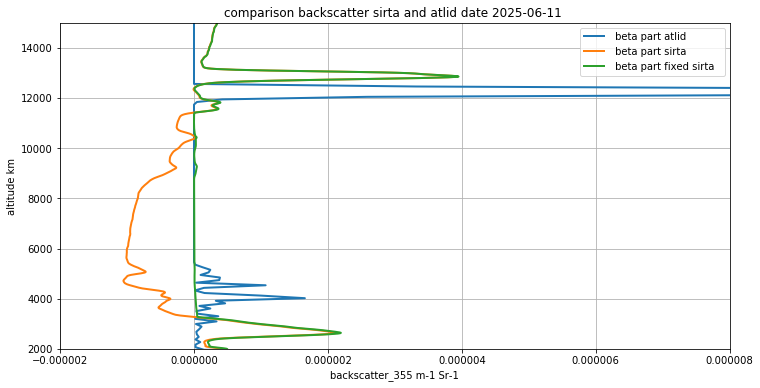

In [72]:
plt.figure(figsize=(12, 6))
plt.plot(backscatter_355_atlid_avrg , altitude_atlid[10 , :] , label=' beta part atlid ' , linewidth=2)
plt.plot(beta_aerosol_total_cloudy_avrg , alt_sirta , label = " beta part sirta  " , linewidth=2)
plt.plot(beta_aerosol_total_cloudy_avrg_fixed , alt_sirta , label = " beta part fixed sirta  " , linewidth=2)
plt.xlabel("backscatter_355 m-1 Sr-1")
plt.ylabel("altitude km")
plt.title(f"comparison backscatter sirta and atlid date {start_time_clear[0:10]} ")
plt.ylim((2000,15000))
plt.xlim((-2e-6,0.8e-5))
plt.grid("True")
plt.legend()    

## save the calibrated data 

In [69]:
output_file = get_calibration_filepath(start_time=start_time_clear, end_time=end_time_clear, output_folder="/homedata/ahaddouche/bdds/SIRTA_L2/Ipral_L1_L2_V2/")
print(output_file)

/homedata/ahaddouche/bdds/SIRTA_L2/Ipral_L1_L2_V2/calibrated_data_IPRAL_20250611_0130-0150.h5


In [70]:
global_attrs = {
    "instrument": "IPRAL",
    "location": "SIRTA - Palaiseau, France",
    "latitude": 48.7127,
    "longitude": 2.2083,
    "title": "IPRAL Lidar Calibration & ATLID Validation",
    "methodology": "Calibration coefficients (K, delta) derived from Clear Sky period and applied to Cloudy Sky period.",
    "history": f"Created on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "processing_level": "L1 (Calibrated ATB) + L2 (Particle Backscatter)",
}



# --- 3. DATA DICTIONARY ---
data_to_save = {
    
    
    # -------------------------------------------------------------------
    # GROUP 2: LEVEL 0 - RAW SIGNALS (BACKGROUND SUBTRACTED)
    # -------------------------------------------------------------------
    
    "Level_0_Pre_Processing": {
        "_description": "Range Corrected Signals (RCS) with background noise subtracted. Non-calibrated.",
        
        # --- ANALOG CHANNELS ---
        "rcs_04_analog_par": {
            "data": rcs_04_rc, 
            "units": "mV * m^2", 
            "long_name": "Analog Parallel (RCS 04) - Background Subtracted"
        },
        "rcs_02_analog_per": {
            "data": rcs_02_rc, 
            "units": "mV * m^2", 
            "long_name": "Analog Perpendicular (RCS 02) - Background Subtracted"
        },
        
        # --- PHOTOCOUNTING CHANNELS ---
        "rcs_05_photo_par": {
            "data": rcs_05_rc, 
            "units": "MHz * m^2", 
            "long_name": "Photocounting Parallel (RCS 05) - Background Subtracted"
        },
        "rcs_03_photo_per": {
            "data": rcs_03_rc, 
            "units": "MHz * m^2", 
            "long_name": "Photocounting Perpendicular (RCS 03) - Background Subtracted"
        },
    },
    
    # -------------------------------------------------------------------
    # GROUP 1: DEFINITIONS
    # -------------------------------------------------------------------
    "Definitions": {
        "altitude": {
            "data": alt_sirta, 
            "units": "m", 
            "long_name": "Altitude above ground level"
        },
        "time_range_calibration": {
            "data": [str(start_time_clear), str(end_time_clear)], 
            "units": "ISO8601", 
            "long_name": "Time window averaged for calibration profile"
        },
        
        "time_range_comparison": {
            "data": [str(start_time_cloud), str(end_time_cloud)], 
            "units": "ISO8601", 
            "long_name": "ATLID overpass colocation time window (Cloudy target)"
        },
    },
    
    # -------------------------------------------------------------------
    # GROUP 2: MOLECULAR REFERENCE MODEL 
    # -------------------------------------------------------------------
    "Molecular_Reference": {
        "_description": "Simulated molecular signals (Rayleigh)",
        
        "beta_ray": {"data": beta_ray, "units": "m-1 sr-1", "long_name": "Molecular Backscatter Coefficient"},
        "alpha_ray": {"data": alpha_ray, "units": "m-1", "long_name": "Molecular Extinction Coefficient"},
        "AMB_clear_total": {"data": AMB_clear, "units": "m-1 sr-1", "long_name": "Attenuated Molecular Backscatter (Total)"},
        "molecular_depol_ratio_used": {"data": depolarization_ratio, "units": "unitless", "long_name": "Molecular depolarization ratio used for AMB separation"},
        
        # The split components you requested
        "AMB_clear_parallel": {"data": AMB_clear_parallel, "units": "m-1 sr-1", "long_name": "Attenuated Molecular Backscatter (Parallel Component)"},
        "AMB_clear_perpendicular": {"data": AMB_clear_perpendicular, "units": "m-1 sr-1", "long_name": "Attenuated Molecular Backscatter (Perpendicular Component)"},
        "beta_ray_parallel": {"data": beta_ray_parallel, "units": "m-1 sr-1", "long_name": "Molecular Backscatter Parallel"},
        "beta_ray_perpendicular": {"data": beta_ray_perpendicular, "units": "m-1 sr-1", "long_name": "Molecular Backscatter Perpendicular"}, 
    
    },

    # -------------------------------------------------------------------
    # GROUP 3: CALIBRATION COEFFICIENTS
    # -------------------------------------------------------------------
    "Calibration_Coefficients": {
        "K_analog_par": {"data": K_analog_par, "units": "au", "long_name": "Slope (K) - Analog Parallel"},
        "delta_analog_par": {"data": delta_analog_par, "units": "mV", "long_name": "Offset (Delta) - Analog Parallel"},
        "K_analog_per": {"data": K_analog_per, "units": "au", "long_name": "Slope (K) - Analog Perpendicular"},
        "delta_analog_per": {"data": delta_analog_per, "units": "mV", "long_name": "Offset (Delta) - Analog Perpendicular"},
        "K_ph_par": {"data": K_ph_par, "units": "au", "long_name": "Slope (K) - Photocounting Parallel"},
        "delta_ph_par": {"data": delta_ph_par, "units": "MHz", "long_name": "Offset (Delta) - Photocounting Parallel"},
        "K_ph_per": {"data": K_ph_per, "units": "au", "long_name": "Slope (K) - Photocounting Perpendicular"},
        "delta_ph_per": {"data": delta_ph_per, "units": "MHz", "long_name": "Offset (Delta) - Photocounting Perpendicular"},
    },

    # -------------------------------------------------------------------
    # GROUP 4: CALIBRATED CLEAR SKY DATA (New!)
    # -------------------------------------------------------------------
    "Calibrated_Clear_Sky": {
        "_description": "Averaged and calibrated ATB for the clear sky period. Used as the reference for calibration.",
        "ATB_total_clear_avg": {"data": ATB_total_clear, "units": "m-1 sr-1", "long_name": "Averaged Total ATB (Clear Sky)"},
        "ATB_par_clear_avg": {"data": ATB_par_Clear, "units": "m-1 sr-1", "long_name": "Averaged Parallel ATB (Clear Sky)"},
        "ATB_per_clear_avg": {"data": ATB_per_Clear, "units": "m-1 sr-1", "long_name": "Averaged Perpendicular ATB (Clear Sky)"},
    },
    # -------------------------------------------------------------------
    # GROUP 5: CALIBRATED CLOUDY DATA 
    # -------------------------------------------------------------------
    "Calibrated_Cloudy_Data": {
        "_description": "Calibrated ATB signals temporally co-located with the ATLID overpass. Contains both the temporal average and profile-by-profile data.",
        # Averages
        "ATB_total_avg": {"data": ATB_total_cloudy_avrg, "units": "m-1 sr-1", "long_name": "Total ATB (Cloudy Avg)"},
        "ATB_par_avg": {"data": ATB_par_cloudy_avrg, "units": "m-1 sr-1", "long_name": "Parallel ATB (Cloudy Avg)"},
        "ATB_per_avg": {"data": ATB_per_cloudy_avrg, "units": "m-1 sr-1", "long_name": "Perpendicular ATB (Cloudy Avg)"},
        
        # Selected Profiles (Added as requested)
        "ATB_total_selected": {"data": ATB_total_cloudy_selected, "units": "m-1 sr-1", "long_name": "Total ATB (Selected Profiles)"},
        "ATB_par_selected": {"data": ATB_par_cloudy_selected, "units": "m-1 sr-1", "long_name": "Parallel ATB (Selected Profiles)"},
        "ATB_per_selected": {"data": ATB_per_cloudy_selected, "units": "m-1 sr-1", "long_name": "Perpendicular ATB (Selected Profiles)"},
        "SR_L1_attenuated": {"data": SR_L1,"units": "unitless", "long_name": "Attenuated Scattering Ratio (ATB_cloudy / AMB_clear)"},
    
        
        "depolarization_ratio_L1_Volume": {
            "data": depol_final, 
            "units": "unitless", 
            "long_name": "Volume Depolarization Ratio (derived from ATB)"
        },},

    
    
    "L2_Products": {
        "_description": "Physical products: Particle Backscatter (Total/Par/Per) for the cloudy comparison period (Averaged and Profile-by-Profile) .",
        
        # --- Inversion Parameters ---
        "lidar_ratio_used": {"data": LR, "units": "sr", "long_name": "Lidar Ratio (LR) used for inversion"},
        "klett_ref_alt": {"data": INDEX_FOR_THE_CALIBRATION, "units": "index", "long_name": "Reference altitude index for Klett calibration"},

        # --- 1. AVERAGED PARTICLE BACKSCATTER (Cloudy Period) ---
        "beta_aerosol_total_avg": {
            "data": beta_aerosol_total_cloudy_avrg, # <-- Vérifie que c'est bien le nom de ta variable Python !
            "units": "m-1 sr-1", 
            "long_name": "Averaged Particle Backscatter Coefficient (Total)"
        },
        "beta_aerosol_par_avg": {
            "data": beta_aerosol_par_cloudy_avrg, 
            "units": "m-1 sr-1", 
            "long_name": "Averaged Particle Backscatter Coefficient (Parallel)"
        },
        "beta_aerosol_per_avg": {
            "data": beta_aerosol_per_cloudy_avrg, 
            "units": "m-1 sr-1", 
            "long_name": "Averaged Particle Backscatter Coefficient (Perpendicular)"
        },
        "beta_aerosol_total_fixed_avg": {
            "data": beta_aerosol_total_cloudy_avrg_fixed, 
            "units": "m-1 sr-1", 
            "long_name": "Averaged Particle Backscatter Total (Fixed: Negatives set to 0)"
        },

        # --- 2. PROFILE-BY-PROFILE PARTICLE BACKSCATTER (Cloudy Period) ---
        "beta_aerosol_total_selected": {
            "data": beta_aerosol_total, 
            "units": "m-1 sr-1", 
            "long_name": "Particle Backscatter Coefficient Total (Profile-by-Profile)"
        },
        "beta_aerosol_total_fixed_selected": {
            "data": beta_aerosol_total_fixed, 
            "units": "m-1 sr-1", 
            "long_name": "Particle Backscatter Total Fixed (Profile-by-Profile)"
        },
        "beta_aerosol_par_selected": {
            "data": beta_aerosol_par, 
            "units": "m-1 sr-1", 
            "long_name": "Particle Backscatter Coefficient Parallel (Profile-by-Profile)"
        },
        "beta_aerosol_per_selected": {
            "data": beta_aerosol_per, 
            "units": "m-1 sr-1", 
            "long_name": "Particle Backscatter Coefficient Perpendicular (Profile-by-Profile)"
        },

        # --- 3. MASKS ---
        "mask_validity_parallel": {
            "data": mask_beta_par, 
            "units": "unitless (bool)", 
            "long_name": "Validity Mask for Parallel Component (1 if beta > 0, else 0)"
        },
        "mask_validity_perpendicular": {
            "data": mask_beta_per, 
            "units": "unitless (bool)", 
            "long_name": "Validity Mask for Perpendicular Component (1 if beta > 0, else 0)"
        },
        
        # --- 4. DERIVED RATIOS (L2) ---
        "SR_L2_physical": {
            "data": SR_ipral_L2, 
            "units": "unitless", 
            "long_name": "True Scattering Ratio (1 + Beta_part/Beta_mol)"
        },
    },
    
    # -------------------------------------------------------------------
    # GROUP 7: VALIDATION (ATLID)
    # -------------------------------------------------------------------
    "Validation_ATLID": {
        "min_index_l2": {"data": min_indx_l2, "units": "index", "long_name": "Closest approach index"},
        "best_index_manual": {"data": best_index, "units": "index", "long_name": "Manually selected ATLID profile index for comparison"},
        "beta_355_full": {"data": backscatter_355_atlid, "units": "m-1 sr-1", "long_name": "ATLID Particle Backscatter "},
        "APB_355_full": {"data": APB_355_atlid, "units": "m-1 sr-1", "long_name": "ATLID Attenuated Particle Backscatter "},
        "AMB_355_full": {"data": AMB_355_atlid, "units": "m-1 sr-1", "long_name": "ATLID Attenuated Molecular Backscatter "},
        "altitude_atlid": {"data": altitude_atlid, "units": "m", "long_name": "ATLID Altitude Grid"},
        "SR_atlid_avg": {"data": SR_atlid, "units": "unitless", "long_name": "ATLID Attenuated Scattering Ratio (ATB / AMB)"
        },
        
    }, }

    
    


# --- 4. SAVE FUNCTION ---
with h5py.File(output_file, "w") as hf:
    # Global Attributes
    hf.attrs["instrument"] = "IPRAL"
    hf.attrs["location"] = "SIRTA"
    hf.attrs["history"] = f"Created on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
    
    print(f"Saving extended dataset to: {output_file}")
    
    for group_name, group_content in data_to_save.items():
        grp = hf.create_group(group_name)
        if "_description" in group_content:
            grp.attrs["description"] = group_content["_description"]
        
        for var_name, var_info in group_content.items():
            if var_name == "_description": continue
            
            data = var_info["data"]
            # Handle strings
            if isinstance(data, list) and isinstance(data[0], str):
                data = np.array(data, dtype=h5py.string_dtype(encoding='utf-8'))
            
            try:
                dset = grp.create_dataset(var_name, data=data)
                dset.attrs["units"] = var_info.get("units", "")
                dset.attrs["long_name"] = var_info.get("long_name", "")
            except Exception as e:
                print(f"  Warning: Could not save {var_name} ({e})")

print("Save complete.")

Saving extended dataset to: /homedata/ahaddouche/bdds/SIRTA_L2/Ipral_L1_L2_V2/calibrated_data_IPRAL_20250611_0130-0150.h5
Save complete.
